In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations
import re
import networkx as nx
import matplotlib.pyplot as plt

stopwords = {
    "the", "and", "of", "to", "in", "a", "for", "is", "on", "that", "with",
    "as", "are", "by", "an", "be", "this", "we", "our", "from", "at", "or",
    "it", "have", "has", "will", "may", "not", "can", "their", "its", "was",
    "were", "which", "also", "than", "into", "these", "those", "such"
}

bad_bigram_words = {
    "includes", "based", "driven", "except", "over",
    "associated", "expected", "recognized", "partially",
    "increase", "decrease"
}

junk_words = {
    "december", "millions", "dollars", "percentages"
}

custom_stopwords = {
    "company", "companies", "business", "fiscal", "year", "years",
    "operations", "results", "financial", "condition", "item",
    "form", "report", "discussion", "analysis", "management",
    "should", "read", "included", "part", "items", "comparisons",
    "annual", "period", "periods", "quarter", "quarters",
    "first", "second", "third", "fourth", "generally",
    "discusses", "discussions", "found", "ended", "during",
    "between", "additional", "every", "week", "weeks",
    "following", "consolidated", "statements", "accompanying", "notes",
    "announcements", "announces", "offerings", "various", "times",
    "including", "could", "future", "other", "new",
    "september", "saturday", "five", "six", "last", "ends",
    "apple", "inc", "compared", "primarily", "due", "total", "change", 
    "asu", "higher", "increased", "months", "within", "payable",
    "partially", "offset", "billion"
}

all_stopwords = stopwords | custom_stopwords

def load_single_mda_text(ticker, year):
    ticker = ticker.upper()
    file_path = Path("..") / "data" / "raw" / ticker / f"{ticker}_{year}_MDA.txt"

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    return text

def get_top_words(tokens, top_n=30):
    word_counts = Counter(tokens)
    return set([word for word, _ in word_counts.most_common(top_n)])

def tokenize_for_graph(text):
    words = re.findall(r"\b[a-z]+\b", text.lower())
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return words

def split_into_sentences(text):
    sentences = re.split(r"[.!?]\s+", text)
    return sentences

def build_cooccurrence_pairs(text, top_words):
    sentences = split_into_sentences(text)
    pair_counts = Counter()

    for sentence in sentences:
        tokens = tokenize_for_graph(sentence)
        tokens = [w for w in tokens if w in top_words]

        unique_tokens = sorted(set(tokens))

        for pair in combinations(unique_tokens, 2):
            pair_counts[pair] += 1

    return pair_counts

def build_graph(pair_counts, min_count=3):
    G = nx.Graph()

    for (word1, word2), count in pair_counts.items():
        if count >= min_count:
            G.add_edge(word1, word2, weight=count)

    return G

def get_filtered_bigrams(tokens, top_n=50, min_count=8):
    bigrams = list(zip(tokens, tokens[1:]))
    counts = Counter(bigrams)

    filtered = []

    for (w1, w2), count in counts.most_common():
        # apply filters
        if count < min_count:
            continue

        if w1 in bad_bigram_words or w2 in bad_bigram_words:
            continue

        if w1 in junk_words or w2 in junk_words:
            continue

        filtered.append(((w1, w2), count))

        if len(filtered) >= top_n:
            break

    return filtered

def build_bigram_cooccurrence_pairs(text, top_bigram_list):
    sentences = split_into_sentences(text)
    pair_counts = Counter()

    top_bigram_strings = {f"{w1} {w2}" for (w1, w2), _ in top_bigram_list}

    for sentence in sentences:
        tokens = tokenize_for_graph(sentence)
        sentence_bigrams = list(zip(tokens, tokens[1:]))

        sentence_bigram_strings = [
            f"{w1} {w2}"
            for (w1, w2) in sentence_bigrams
            if f"{w1} {w2}" in top_bigram_strings
        ]

        unique_bigrams = sorted(set(sentence_bigram_strings))

        for pair in combinations(unique_bigrams, 2):
            pair_counts[pair] += 1

    return pair_counts

def build_bigram_graph(pair_counts, min_count=2):
    G = nx.Graph()

    for (bigram1, bigram2), count in pair_counts.items():
        if count >= min_count:
            G.add_edge(bigram1, bigram2, weight=count)

    return G

Nodes: 30
Edges: 332


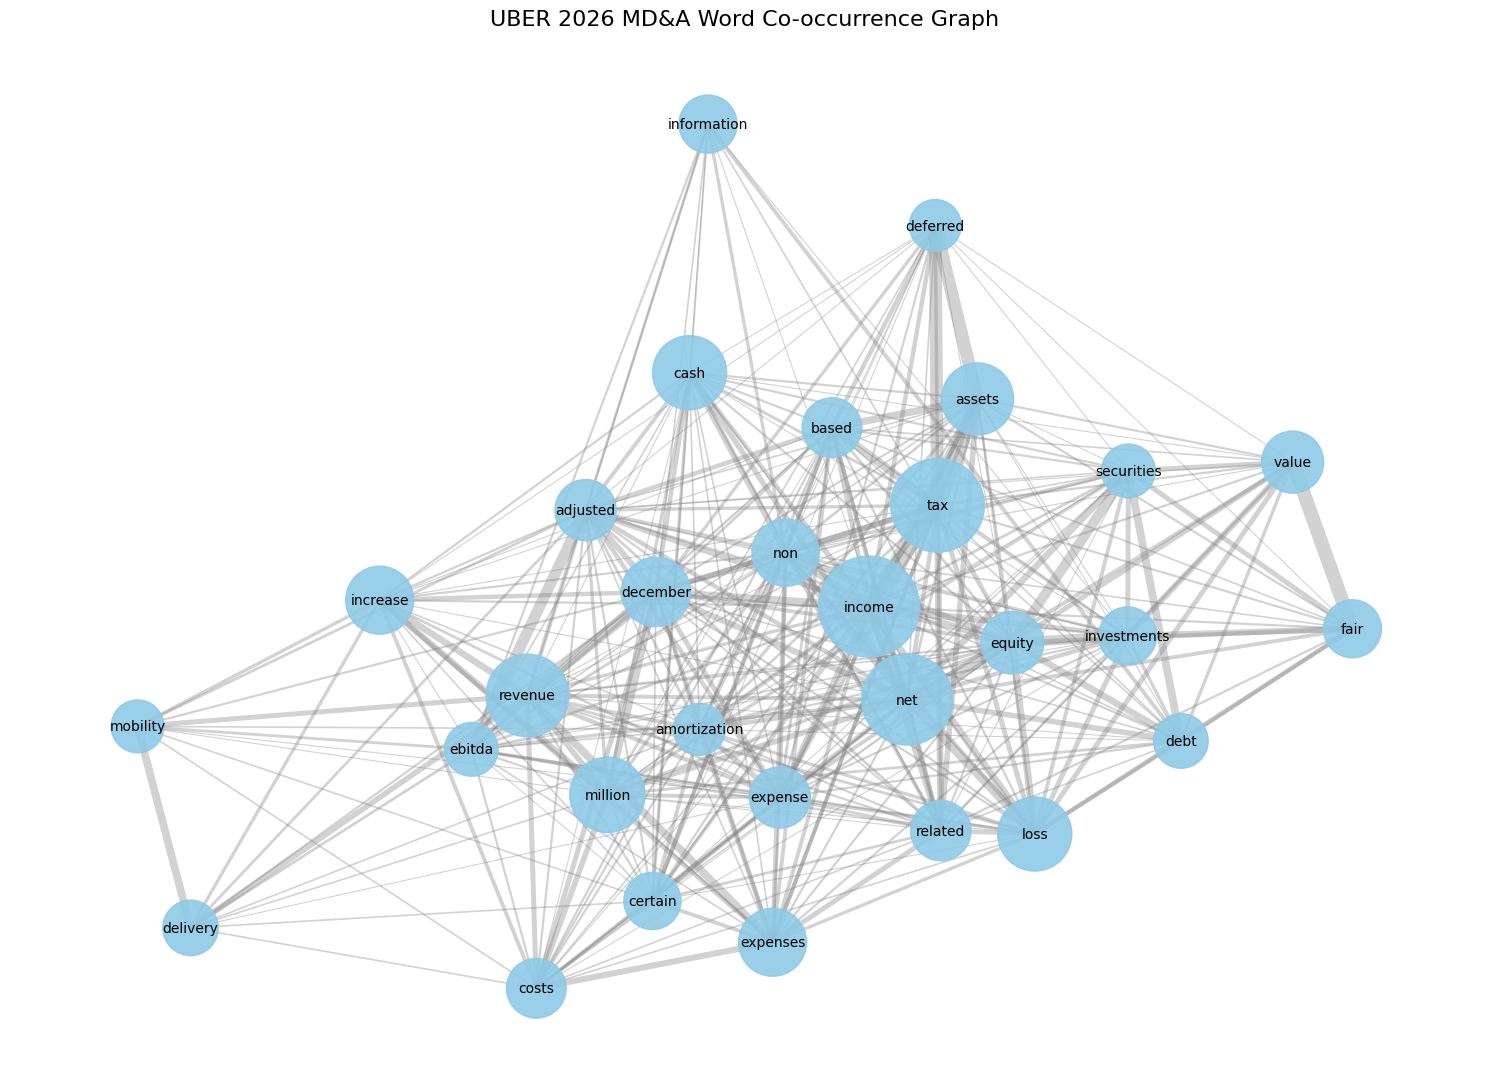

In [2]:
company = "UBER"
yr = "2026"

text = load_single_mda_text(company, yr)
tokens = tokenize_for_graph(text)
top_words = get_top_words(tokens, top_n=30)

pair_counts = build_cooccurrence_pairs(text, top_words)
G = build_graph(pair_counts, min_count=2)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

word_counts = Counter(tokens)

node_sizes = [word_counts[node] * 50 for node in G.nodes()]


plt.figure(figsize=(15, 11), facecolor="white")

pos = nx.spring_layout(G, seed=42, k=1.2, iterations=100)

edge_widths = [G[u][v]["weight"] * 0.4 for u, v in G.edges()]

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color="#8ecae6",
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.35,
    edge_color="gray"
)

label_nodes = {node: node for node in G.nodes() if word_counts[node] >= 8}
nx.draw_networkx_labels(
    G, pos,
    labels=label_nodes,
    font_size=10,
    font_color="black"
)

plt.title(company + " " + yr + " " + "MD&A Word Co-occurrence Graph", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
top_bigrams = get_filtered_bigrams(tokens)

for (w1, w2), count in top_bigrams:
    print(f"{w1} {w2}: {count}")

fair value: 31
adjusted ebitda: 30
deferred tax: 26
tax assets: 26
net income: 25
gross bookings: 22
depreciation amortization: 22
income taxes: 22
supplementary data: 21
equity method: 18
valuation allowance: 17
percentage revenue: 17
method investments: 17
net unrealized: 16
equity securities: 15
see note: 15
income loss: 15
unrealized gain: 14
income tax: 14
net cash: 13
non gaap: 13
gaap measures: 13
million net: 13
information see: 13
loss equity: 13
cost revenue: 12
intangible assets: 12
all available: 12
more likely: 12
mobility delivery: 11
revenue exclusive: 11
exclusive depreciation: 11
research development: 11
constant currency: 10
investment million: 10
sales marketing: 10
general administrative: 10
interest expense: 10
non controlling: 10
controlling interests: 10
non income: 10
cash flows: 9
cash flow: 9
long term: 9
term debt: 9
interest income: 9
income expense: 9
expense net: 9
allowance against: 9
positive negative: 9


Nodes: 38
Edges: 141


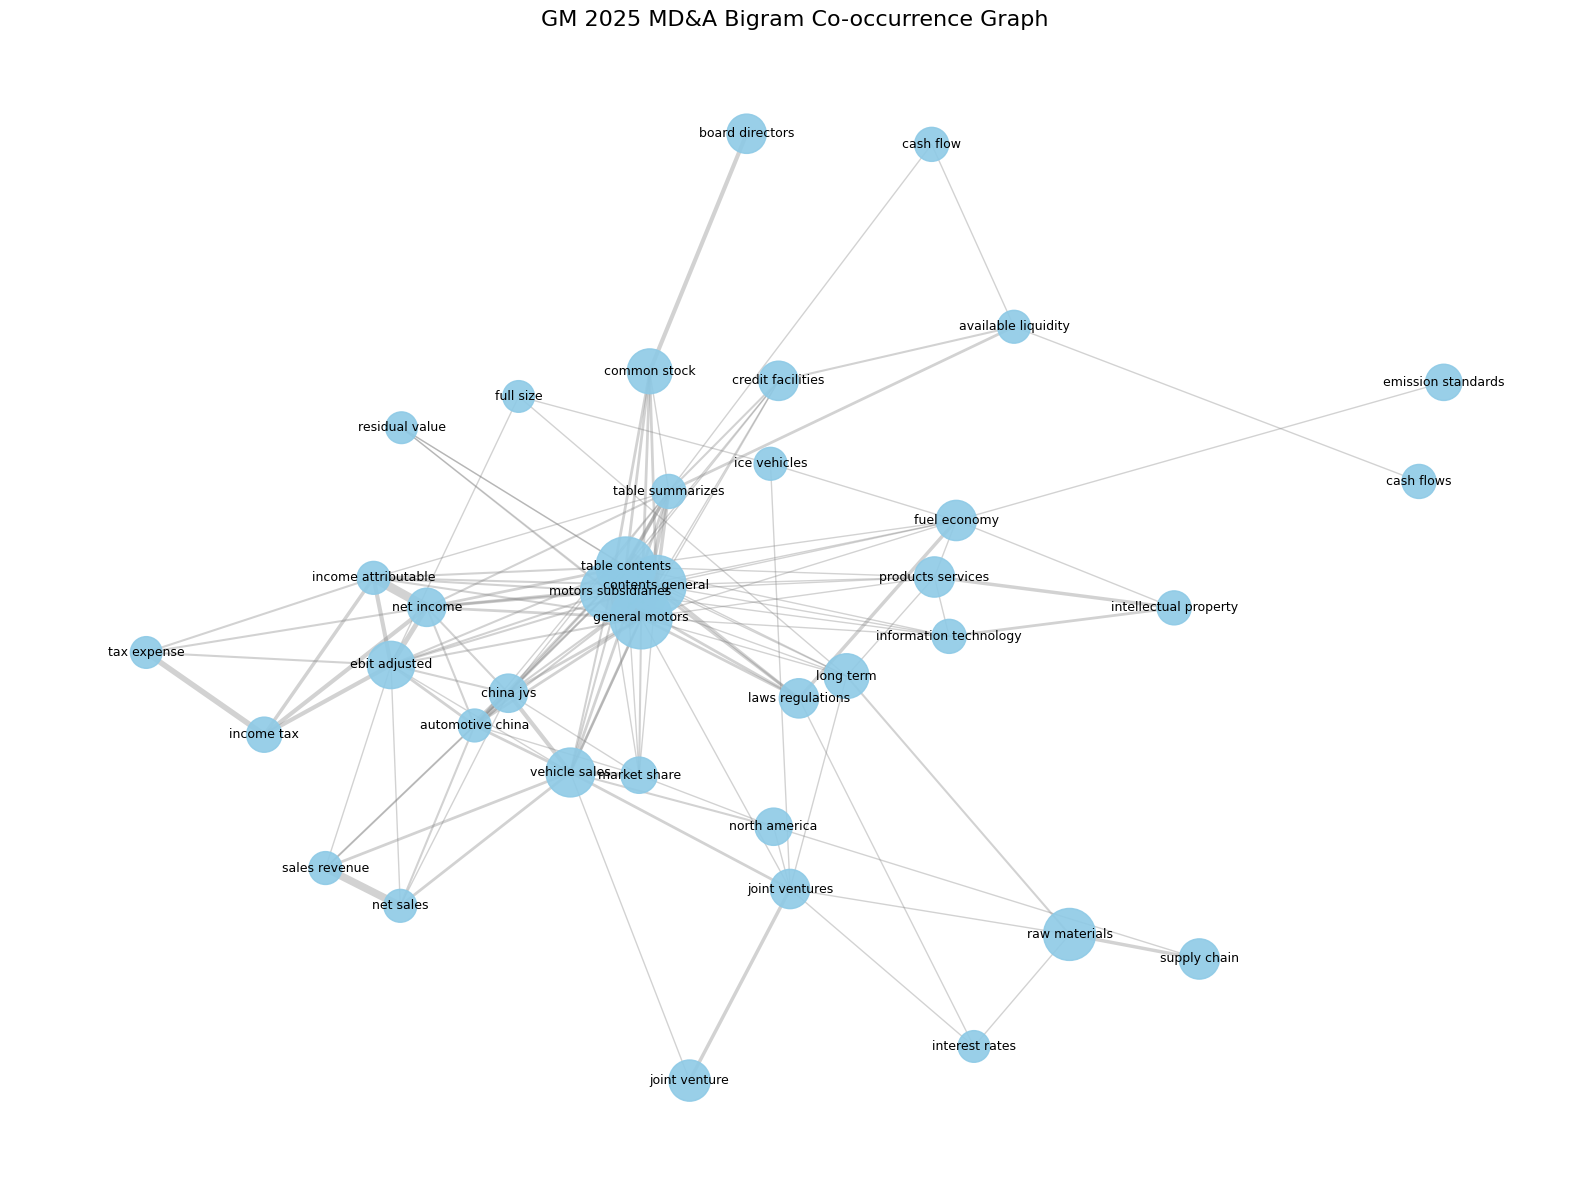

In [4]:
company = "GM"
yr = "2025"

text = load_single_mda_text(company, yr)
tokens = tokenize_for_graph(text)

top_bigrams = get_filtered_bigrams(tokens, top_n=40, min_count=1)

bigram_pair_counts = build_bigram_cooccurrence_pairs(text, top_bigrams)
G = build_bigram_graph(bigram_pair_counts, min_count=2)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

bigram_count_dict = {f"{w1} {w2}": count for (w1, w2), count in top_bigrams}
node_sizes = [bigram_count_dict.get(node, 1) * 40 for node in G.nodes()]

plt.figure(figsize=(16, 12), facecolor="white")

pos = nx.spring_layout(G, seed=42, k=1.4, iterations=100)
edge_widths = [G[u][v]["weight"] * 0.5 for u, v in G.edges()]

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color="#8ecae6",
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.35,
    edge_color="gray"
)

label_nodes = {node: node for node in G.nodes() if bigram_count_dict.get(node, 0) >= 3}
nx.draw_networkx_labels(
    G, pos,
    labels=label_nodes,
    font_size=9,
    font_color="black"
)

plt.title(f"{company} {yr} MD&A Bigram Co-occurrence Graph", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()